In [10]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
iris = sns.load_dataset('iris')

In [12]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [13]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [14]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

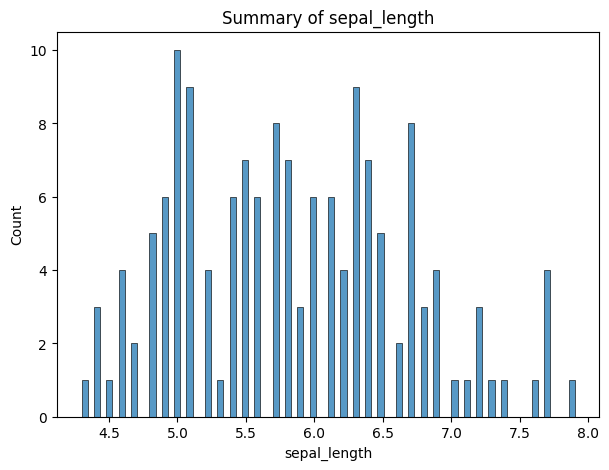

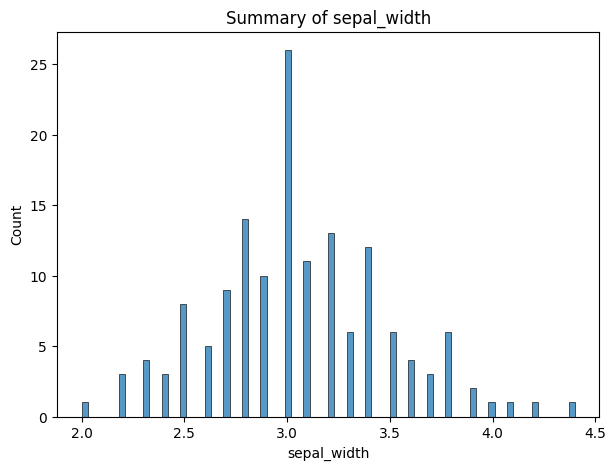

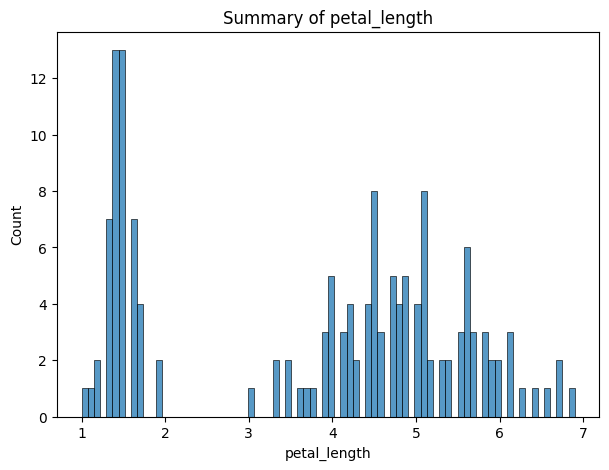

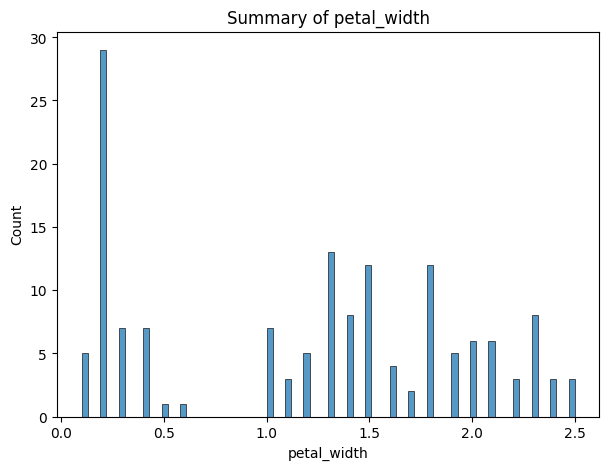

In [25]:
# iris.hist(figsize = (15,12), bins = 30)
for col in iris.columns[:-1]:
    plt.figure(figsize = (7,5))
    sns.histplot(iris[col], bins = 80)
    plt.title(f"Summary of {col}")
    plt.show()

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

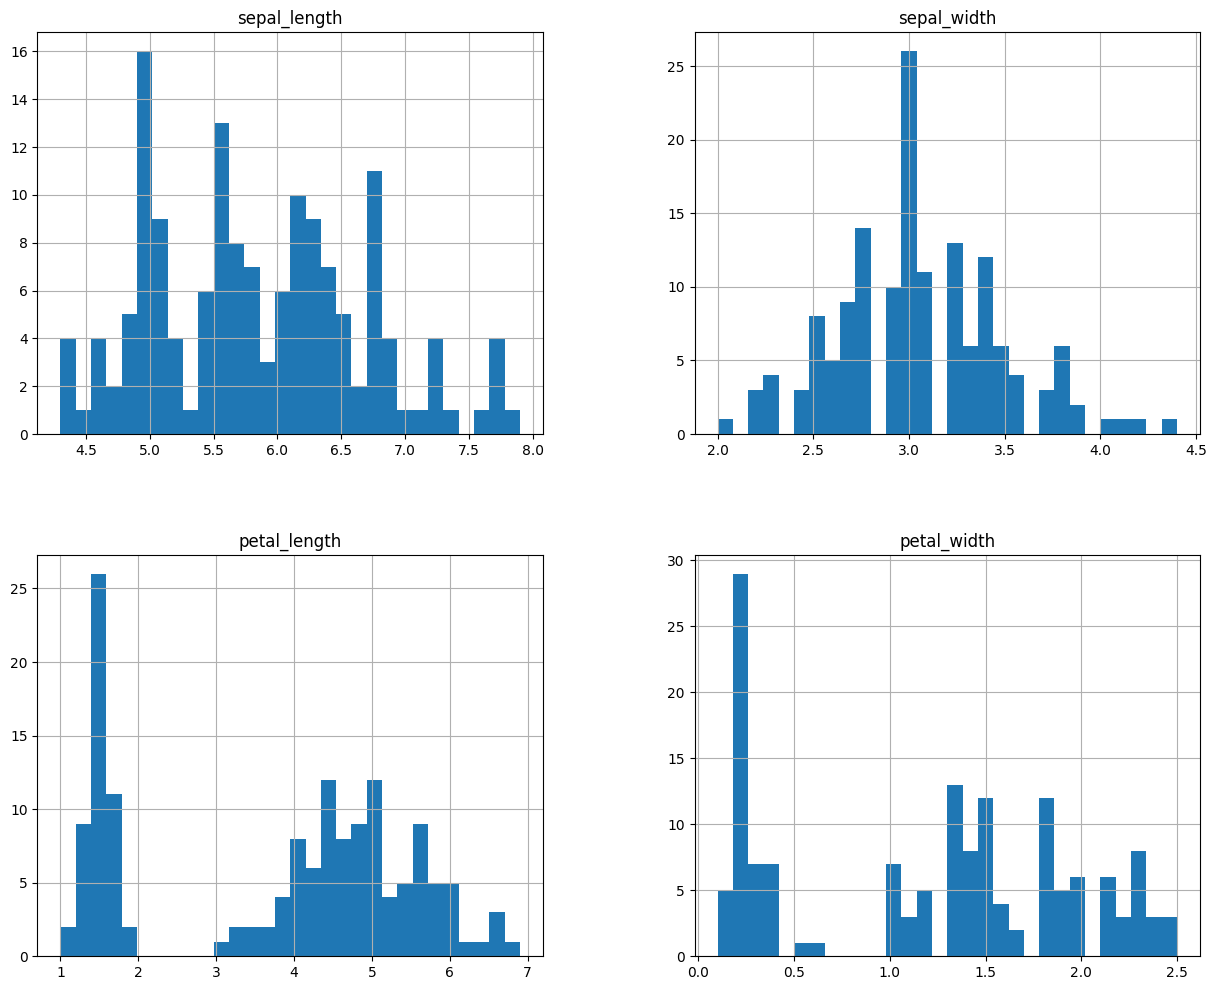

In [26]:
iris.hist(figsize = (15,12), bins = 30)


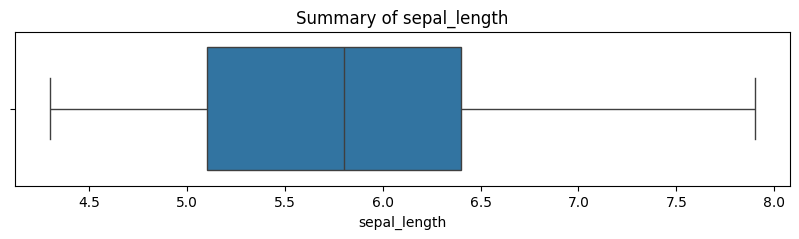

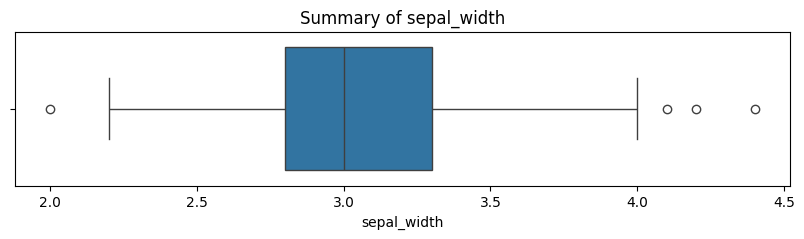

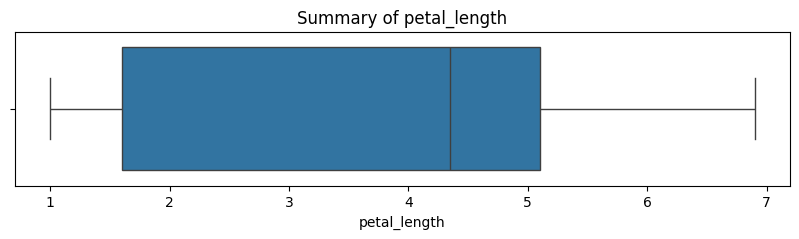

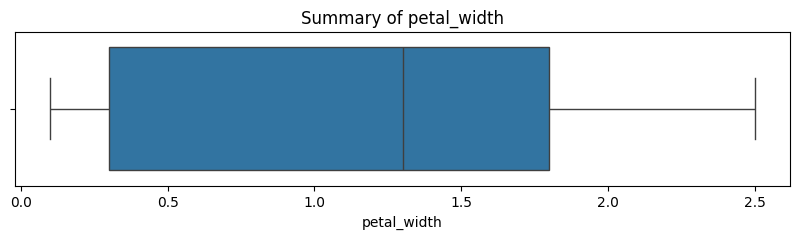

In [27]:

for col in iris.columns[:-1]:
    plt.figure(figsize = (10,2))
    sns.boxplot(x=col,data = iris)
    plt.title(f"Summary of {col}")
    plt.show()



Feature: sepal_length
  Mean: 5.84, Median: 5.80, Std Dev: 0.83
  Outliers Detected: No 
----------------------------------------

Feature: sepal_width
  Mean: 3.06, Median: 3.00, Std Dev: 0.44
  Outliers Detected: Yes 
  Outlier Values: [4.4, 4.1, 4.2, 2.0]
----------------------------------------

Feature: petal_length
  Mean: 3.76, Median: 4.35, Std Dev: 1.77
  Outliers Detected: No 
----------------------------------------

Feature: petal_width
  Mean: 1.20, Median: 1.30, Std Dev: 0.76
  Outliers Detected: No 
----------------------------------------


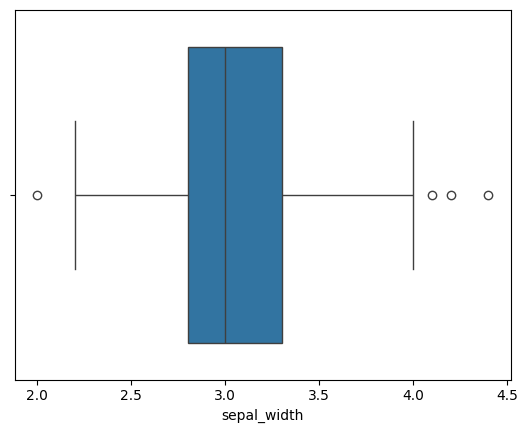

In [28]:
for column in iris.columns[:-1]:  # Exclude 'species' column
    Q1 = iris[column].quantile(0.25)
    Q3 = iris[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = iris[column].apply(lambda x : x if ( x < lower_bound or x > upper_bound ) else None).dropna()
    # outliers = outliers.dropna()

    print(f"\nFeature: {column}")
    print(f"  Mean: {iris[column].mean():.2f}, Median: {iris[column].median():.2f}, Std Dev: {iris[column].std():.2f}")
    print(f"  Outliers Detected: {'No' if outliers.empty else 'Yes'}","\n  " f"Outlier Values: {outliers.tolist()}" if not outliers.empty else "")
    if not outliers.empty:
        sns.boxplot(x = column, data = iris)
    print("-" * 40)